# 🧪 Fine-Tuning com LoRA — Modelo Causal 2
## `bigscience/bloom-560m`

Este notebook aplica **LoRA (Low-Rank Adaptation)** ao modelo `bloom-560m`,
um modelo causal multilingual treinado em 46 idiomas, incluindo português.

### Por que este modelo?
- O BLOOM-560m foi treinado pelo BigScience em corpus multilingual massivo (ROOTS),
  cobrindo 46 línguas naturais e 13 linguagens de programação.
- Diferente do `gpt2-small-portuguese` (especializado em PT-BR), o BLOOM **não tem
  especialização em português**: ele conhece o idioma, mas não tem prior específico.
- Isso permite uma **comparação direta** entre:
  - **Causal 1** (`gpt2-small-portuguese`): modelo com forte prior em PT-BR
  - **Causal 2** (`bloom-560m`): modelo multilingual sem especialização em PT
- A comparação responde: *o prior linguístico em português ajuda mais do que
  o maior tamanho e a capacidade multilingual do BLOOM?*

### Arquitetura BLOOM vs GPT-2
| Aspecto | GPT-2 Small PT | BLOOM-560m |
|---|---|---|
| Parâmetros | ~124M | ~560M |
| Línguas | PT-BR (especializado) | 46 línguas |
| Atenção | `c_attn` + `c_proj` (Conv1D) | `query_key_value` + `dense` (Linear) |
| Normalização | LayerNorm pré-atenção | ALiBi + LayerNorm |
| Embedding posicional | Posicional absoluto | ALiBi (sem embedding posicional) |

### Correções críticas aplicadas
- **Mascaramento de labels**: loss calculado **apenas sobre os tokens do Output**
- **`default_data_collator`**: preserva os labels com `-100` sem sobrescrevê-los
- **BOS offset**: detecção automática de token especial de início
- **`target_modules` corretos para BLOOM**: `query_key_value` e `dense`


## 📦 1. Instalação das dependências


In [ ]:
!pip install -q transformers datasets peft accelerate sentencepiece
!pip uninstall -y torchao 2>/dev/null || true


Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0


## 🔗 2. Montar o Google Drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## 📥 3. Importações


In [ ]:
import torch
import json
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    TrainingArguments,
    Trainer,
    default_data_collator  # preserva labels com mascaramento (-100)
)
from peft import LoraConfig, get_peft_model

print(f"PyTorch: {torch.__version__}")
print(f"GPU disponível: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM disponível: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


PyTorch: 2.11.0+cu128
GPU disponível: True
GPU: Tesla T4
VRAM disponível: 15.6 GB


## 📂 4. Carregar e Preparar o Dataset

### Formato do texto
Cada exemplo é convertido para:
```
Instruction: <pergunta>
Output: <resposta>
```

### ⚠️ Correção crítica: mascaramento de labels
A função `tokenize_with_label_masking` garante que o loss seja calculado
**apenas nos tokens do Output**, e não na instrução inteira.

Isso é feito atribuindo `-100` às posições da instrução nos `labels`.
O PyTorch/HuggingFace ignora automaticamente posições com `-100` no cálculo do CrossEntropyLoss.


In [ ]:
# ── Configuração ──────────────────────────────────────────────────────────────
DATASET_PATH   = "/content/drive/MyDrive/dataset_gerado_v3 (1).jsonl"
MODEL_SAVE_PATH = "/content/drive/MyDrive/lora_causal_model_2"
MAX_LENGTH     = 256
# ──────────────────────────────────────────────────────────────────────────────

def convert_to_hf_format(example):
    """Combina instrução e saída em um único texto formatado."""
    return {
        "text": f"Instruction: {example['Instruction']}\nOutput: {example['Output']}"
    }

# Carrega o dataset
dataset = load_dataset("json", data_files=DATASET_PATH)
dataset = dataset.map(convert_to_hf_format)

# Divide em treino (80%) e teste (20%) — mesma seed do Causal 1 para comparação justa
dataset = dataset["train"].train_test_split(test_size=0.2, seed=42)

print(dataset)
print("\nExemplo de texto:")
print(dataset["train"][0]["text"])

Generating train split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/152 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['Instruction', 'Output', 'text'],
        num_rows: 121
    })
    test: Dataset({
        features: ['Instruction', 'Output', 'text'],
        num_rows: 31
    })
})

Exemplo de texto:
Instruction: Como garantir um desempenho máximo e economia em operações ao usar este equipamento?
Output: Para maximizar o desempenho e a economia de operações, é crucial seguir todas as recomendações de segurança, cuidados e manutenção. Isso inclui regularmente ajustar e inspecionar rapidamente os componentes de disco, manter os parafusos afrouxados e monitorar a velocidade do trator conforme solicitado.


## 🤖 5. Carregar o Modelo e o Tokenizador

### Particularidades do BLOOM-560m

**Pad token**: diferente do GPT-2, o BLOOM já possui um `pad_token` dedicado (`<pad>`),
então não é necessário redefinir para `eos_token`.

**Precisão**: o BLOOM foi treinado em `bfloat16`, mas a GPU T4 do Colab não suporta
bf16 nativamente de forma eficiente. Usamos `float32` para garantir compatibilidade.
Se a GPU for A100 ou H100, pode-se trocar para `torch.bfloat16`.

**Tamanho**: com 560M parâmetros, o BLOOM ocupa ~2.2 GB em float32.
Isso reduz o batch size disponível na T4 (16 GB VRAM).


In [ ]:
model_name = "bigscience/bloom-560m"

print(f"Carregando tokenizador: {model_name}")
tokenizer = AutoTokenizer.from_pretrained(model_name)

# BLOOM já possui pad_token dedicado ('<pad>'), diferente do GPT-2
print(f"pad_token: '{tokenizer.pad_token}' (id={tokenizer.pad_token_id})")
print(f"eos_token: '{tokenizer.eos_token}' (id={tokenizer.eos_token_id})")

print(f"\nCarregando modelo base: {model_name}")
base_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float32,  # float32 para compatibilidade com T4
)

total_params = sum(p.numel() for p in base_model.parameters())
print(f"\nModelo carregado: {model_name}")
print(f"Total de parâmetros: {total_params:,}")
print(f"Memória estimada (float32): {total_params * 4 / 1e9:.2f} GB")


Carregando tokenizador: bigscience/bloom-560m


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/693 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/222 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/14.5M [00:00<?, ?B/s]

...

pad_token: '<pad>' (id=3)
eos_token: '</s>' (id=2)

Carregando modelo base: bigscience/bloom-560m


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/293 [00:00<?, ?it/s]


Modelo carregado: bigscience/bloom-560m
Total de parâmetros: 559,214,592
Memória estimada (float32): 2.24 GB


## 🧪 6. Inferência ANTES do Fine-Tuning (Modelo Base)

Registramos a resposta do modelo **sem qualquer ajuste**, para comparação posterior.
Espera-se que o modelo base gere texto em português (pois BLOOM conhece o idioma),
mas sem conhecimento específico sobre a Grade Hidráulica GH da Marchesan.

Essa é a diferença qualitativa central em relação ao Causal 1: o BLOOM base
pode gerar português fluente, mas genérico — o GPT-2 PT base gera português
mais idiomático mas igualmente sem conhecimento do domínio.


In [ ]:
def generate_response(model, tokenizer, instruction, max_new_tokens=80):
    """
    Gera uma resposta a partir de uma instrução.
    Extrai apenas o conteúdo após 'Output:'.

    Usa num_beams=3 (beam search leve) em vez de repetition_penalty,
    que pode suprimir termos técnicos válidos que aparecem na instrução.
    """
    prompt = f"Instruction: {instruction}\nOutput:"
    device = next(model.parameters()).device

    inputs = tokenizer(prompt, return_tensors="pt", padding=False)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model.generate(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            max_new_tokens=max_new_tokens,
            pad_token_id=tokenizer.pad_token_id,  # BLOOM usa <pad>, não eos
            do_sample=False,
            num_beams=3,
            early_stopping=True,
        )

    full_output = tokenizer.decode(outputs[0], skip_special_tokens=True)
    resposta = full_output.split("Output:")[-1].strip()
    return resposta


# Pergunta de teste — mesma do Causal 1 para comparação direta
test_instruction = "Qual é a recomendação para transportar o equipamento por longas distâncias?"

print("=" * 60)
print("ANTES DO FINE-TUNING (modelo base BLOOM-560m)")
print("=" * 60)
print(f"Instrução: {test_instruction}")
print(f"Resposta:  {generate_response(base_model, tokenizer, test_instruction)}")


ANTES DO FINE-TUNING (modelo base BLOOM-560m)
Instrução: Qual é a recomendação para transportar o equipamento por longas distâncias?
Resposta:  Qual é a recomendação para transportar o equipamento por longas distâncias? Qual é a recomendação para transportar o equipamento por longas distâncias? Qual é a recomendação para transportar o equipamento por longas distâncias? Qual é a recomendação para transportar o equipamento por longas distâncias? Qual é a recomendação para transportar o equipamento por longas distâncias? Qual é a recomendação para transportar o equipamento por longas distâncias? Qual é


## ✂️ 7. Tokenização com Mascaramento de Labels

### Por que mascarar?
Sem mascaramento, o modelo calcula loss sobre a instrução inteira, aprendendo
a "falar sobre o domínio" genericamente. Com mascaramento, ele é forçado a
aprender **o que responder dado uma pergunta específica**.

### Como funciona:
1. Tokenizamos o texto completo (`Instruction: ... \nOutput: ...`)
2. Tokenizamos apenas a parte da instrução (`Instruction: ...\nOutput:`)
3. Os primeiros `len(instrução) + bos_offset` tokens nos labels recebem `-100`
4. O loss é calculado apenas nos tokens restantes (a resposta)

### Nota sobre o BOS token no BLOOM
O BLOOM adiciona um token `<s>` (BOS) no início de cada sequência quando
`add_special_tokens=True`. Detectamos esse offset automaticamente para
garantir que o mascaramento esteja alinhado com os `input_ids` reais.


In [ ]:
def tokenize_with_label_masking(examples):
    """
    Tokeniza os exemplos e mascara os tokens da instrução nos labels.
    Os tokens com label=-100 são ignorados no cálculo do CrossEntropyLoss.

    Correção BOS offset: o BLOOM adiciona token <s> no início com
    add_special_tokens=True. Detectamos e compensamos esse deslocamento.
    """
    tokenized = tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH
    )

    all_labels = []

    for i, text in enumerate(examples["text"]):
        input_ids = tokenized["input_ids"][i]

        # Parte da instrução (tudo até e incluindo "Output:")
        instruction_part = text.split("\nOutput:")[0] + "\nOutput:"
        instruction_tokens = tokenizer(
            instruction_part,
            add_special_tokens=False  # sem BOS — aplicamos o offset manualmente
        )["input_ids"]

        # Comprimento real da instrução no texto completo tokenizado
        instruction_len = len(instruction_tokens) + bos_offset

        # Cria os labels: -100 na instrução, input_ids no Output
        labels = [-100] * instruction_len + input_ids[instruction_len:]

        # Garante comprimento igual ao input_ids (padding com -100)
        labels = labels[:MAX_LENGTH]
        labels = labels + [-100] * (MAX_LENGTH - len(labels))

        all_labels.append(labels)

    tokenized["labels"] = all_labels
    return tokenized

# Detecta se o tokenizador insere BOS token (offset entre texto completo e parte isolada)
_probe          = tokenizer("teste", add_special_tokens=True)["input_ids"]
_probe_no_spec  = tokenizer("teste", add_special_tokens=False)["input_ids"]
bos_offset = len(_probe) - len(_probe_no_spec)  # 1 se há BOS, 0 caso contrário

print("Tokenizando dataset com mascaramento de labels...")
tokenized_datasets = dataset.map(
    tokenize_with_label_masking,
    batched=True,
    remove_columns=dataset["train"].column_names
)

print("Dataset tokenizado:", tokenized_datasets)

# Verificação: mostra quantos tokens são -100 (instrução) vs ativos (output)
sample_labels = tokenized_datasets["train"][0]["labels"]
n_masked = sum(1 for l in sample_labels if l == -100)
n_active = sum(1 for l in sample_labels if l != -100)
print(f"\nVerificação no 1º exemplo:")
print(f"  Tokens mascarados (instrução + BOS offset): {n_masked}")
print(f"  Tokens ativos (output/loss):                {n_active}")
print(f"  BOS offset detectado:                       {bos_offset}")


Tokenizando dataset com mascaramento de labels...


Map:   0%|          | 0/121 [00:00<?, ? examples/s]

Map:   0%|          | 0/31 [00:00<?, ? examples/s]

Dataset tokenizado: DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 121
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 31
    })
})

Verificação no 1º exemplo:
  Tokens mascarados (instrução + BOS offset): 17
  Tokens ativos (output/loss):                239
  BOS offset detectado:                       0


## 🧩 8. Configurar e Injetar LoRA

### Justificativa dos hiperparâmetros

| Parâmetro | Valor | Justificativa |
|---|---|---|
| `r` | 8 | Rank menor que o Causal 1 (r=16). O BLOOM-560m tem ~4.5x mais parâmetros que o GPT-2 small PT, portanto cada camada tem maior capacidade interna. Um rank menor é suficiente e mais eficiente em memória. |
| `lora_alpha` | 16 | Escala efetiva α/r = 16/8 = 2.0 — mesma proporção do Causal 1, mantendo intensidade de adaptação comparável. |
| `target_modules` | query_key_value, dense | **Específico para BLOOM**. O BLOOM funde Q, K e V em uma única projeção `query_key_value` (diferente do GPT-2 que usa `c_attn`). `dense` é a projeção de saída da atenção (equivalente ao `c_proj` do GPT-2). |
| `lora_dropout` | 0.05 | Dropout leve como regularizador. Mantido igual ao Causal 1 para comparação controlada. |
| `bias` | none | Não treinar vieses reduz parâmetros sem impacto relevante na qualidade. |

### Por que `query_key_value` e `dense` no BLOOM?
A arquitetura BLOOM usa `transformers.models.bloom.modeling_bloom.BloomAttention`,
onde a projeção de atenção é unificada em `query_key_value` (dim → 3*dim) e a
saída passa por `dense` (dim → dim). Isso é diferente do GPT-2 (`c_attn` + `c_proj`)
e de modelos LLaMA/OPT (`q_proj`, `k_proj`, `v_proj`, `o_proj`).

Para confirmar os nomes corretos no modelo:
```python
for name, _ in base_model.named_modules():
    if 'attention' in name.lower():
        print(name)
```


In [ ]:
# Opcional: inspecionar nomes das camadas de atenção para confirmar target_modules
print("Camadas de atenção no BLOOM-560m:")
for name, module in base_model.named_modules():
    if any(k in name for k in ["query_key_value", "dense", "c_attn", "c_proj"]):
        print(f"  {name} — {type(module).__name__}")

print()

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    # Módulos de atenção específicos da arquitetura BLOOM
    # query_key_value: projeção unificada de Q, K, V
    # dense: projeção de saída da atenção (equivalente ao c_proj do GPT-2)
    target_modules=["query_key_value", "dense"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    inference_mode=False
)

model = get_peft_model(base_model, lora_config)
model.print_trainable_parameters()


Camadas de atenção no BLOOM-560m:
  transformer.h.0.self_attention.query_key_value — Linear
  transformer.h.0.self_attention.dense — Linear
  transformer.h.0.mlp.dense_h_to_4h — Linear
  transformer.h.0.mlp.dense_4h_to_h — Linear
  transformer.h.1.self_attention.query_key_value — Linear
  transformer.h.1.self_attention.dense — Linear
  transformer.h.1.mlp.dense_h_to_4h — Linear
  transformer.h.1.mlp.dense_4h_to_h — Linear
  transformer.h.2.self_attention.query_key_value — Linear
  transformer.h.2.self_attention.dense — Linear
  transformer.h.2.mlp.dense_h_to_4h — Linear
  transformer.h.2.mlp.dense_4h_to_h — Linear
  transformer.h.3.self_attention.query_key_value — Linear
  transformer.h.3.self_attention.dense — Linear
  transformer.h.3.mlp.dense_h_to_4h — Linear
  transformer.h.3.mlp.dense_4h_to_h — Linear
  transformer.h.4.self_attention.query_key_value — Linear
  transformer.h.4.self_attention.dense — Linear
  transformer.h.4.mlp.dense_h_to_4h — Linear
  transformer.h.4.mlp.dense_4h_

## 🧱 9. Data Collator

Usamos `default_data_collator` em vez de `DataCollatorForLanguageModeling`.

**Motivo**: o `DataCollatorForLanguageModeling(mlm=False)` pode sobrescrever
os `labels` com cópias diretas de `input_ids`, anulando o mascaramento de `-100`
aplicado em `tokenize_with_label_masking`.

O `default_data_collator` apenas agrupa os exemplos em batches sem modificar
nenhum campo, preservando os labels exatamente como foram definidos.
Como usamos `padding="max_length"` na tokenização, todos os exemplos já têm
o mesmo comprimento — não há necessidade de padding dinâmico no collator.


In [ ]:
# default_data_collator: agrupa exemplos em batch sem modificar labels
data_collator = default_data_collator


## ⚙️ 10. Argumentos de Treinamento

### Justificativa dos hiperparâmetros

| Parâmetro | Valor | Justificativa |
|---|---|---|
| `learning_rate` | 1e-4 | Mais conservador que o Causal 1 (2e-4). O BLOOM é maior (~560M vs ~124M parâmetros); LRs maiores aumentam o risco de instabilidade com dataset pequeno. |
| `num_train_epochs` | 10 | Mesmas épocas do Causal 1 para comparação controlada. Com dataset pequeno, monitorar eval_loss para identificar overfitting. |
| `per_device_train_batch_size` | 2 | Reduzido em relação ao Causal 1 (batch=4). O BLOOM-560m ocupa ~2.2 GB em float32; batch 2 evita OOM na GPU T4 (16 GB). |
| `gradient_accumulation_steps` | 2 | Compensa o batch menor: batch efetivo = 2×2 = 4, igual ao Causal 1. Mantém comparação justa. |
| `weight_decay` | 0.01 | Regularização L2 leve, padrão para fine-tuning com PEFT. |
| `eval_steps` | 50 | Avalia a cada 50 steps para monitorar overfitting com dataset pequeno. |
| `metric_for_best_model` | eval_loss | Define explicitamente que o melhor checkpoint é o de menor eval_loss. |
| `greater_is_better` | False | Loss menor = modelo melhor. Necessário com `load_best_model_at_end=True`. |


In [ ]:
training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/results_causal_2",
    eval_strategy="steps",
    eval_steps=50,
    learning_rate=1e-4,                  # menor que Causal 1 — modelo maior
    per_device_train_batch_size=2,       # reduzido para caber na VRAM com BLOOM-560m
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=2,       # batch efetivo = 2×2 = 4 (igual ao Causal 1)
    num_train_epochs=10,
    weight_decay=0.01,
    logging_steps=10,
    save_strategy="steps",
    save_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    report_to="none",
    fp16=torch.cuda.is_available(),      # fp16 se GPU disponível
)


## 🏋️ 11. Treinar o Modelo


In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    data_collator=data_collator,
)

print("Iniciando treinamento...")
train_result = trainer.train(resume_from_checkpoint=True)
print("\nTreinamento concluído!")
print(f"Loss final de treino: {train_result.training_loss:.4f}")

Iniciando treinamento...


Step,Training Loss,Validation Loss
50,7.906874,6.540086
100,0.881756,0.865249
150,0.747468,0.784508
200,0.724119,0.800912
250,0.864921,0.844101
300,0.914461,0.876552
310,0.854608,0.876841



Treinamento concluído!
Loss final de treino: 3.1862


## 📊 12. Gráfico de Loss por Época

Plotamos train loss e eval loss juntos para identificar overfitting.
O gráfico será comparado ao do Causal 1 para análise no relatório.


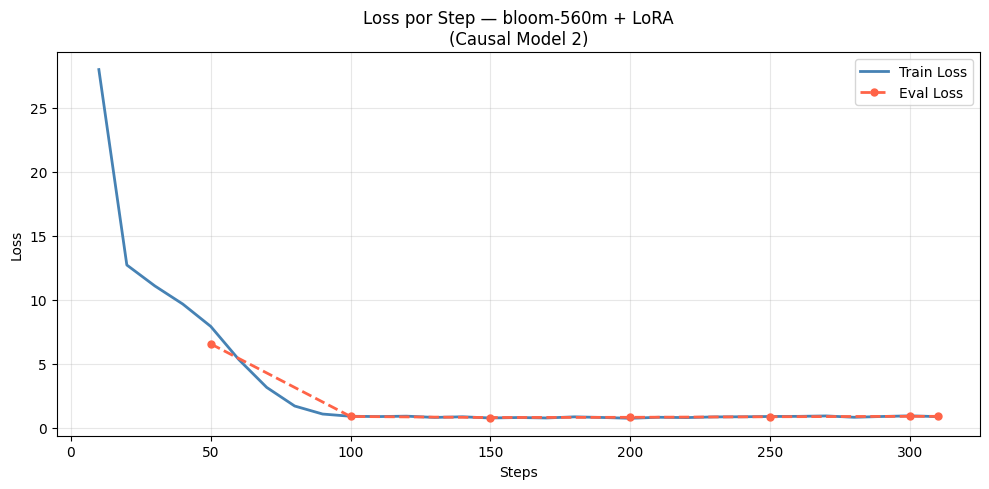

Gráfico salvo em: /content/drive/MyDrive/loss_causal_model_2.png


In [ ]:
log_history = trainer.state.log_history

train_steps, train_losses = [], []
eval_steps, eval_losses   = [], []

for entry in log_history:
    if "loss" in entry and "eval_loss" not in entry:
        train_steps.append(entry["step"])
        train_losses.append(entry["loss"])
    if "eval_loss" in entry:
        eval_steps.append(entry["step"])
        eval_losses.append(entry["eval_loss"])

plt.figure(figsize=(10, 5))
plt.plot(train_steps, train_losses, label="Train Loss", color="steelblue", linewidth=2)
plt.plot(eval_steps, eval_losses, label="Eval Loss", color="tomato",
         linewidth=2, linestyle="--", marker="o", markersize=5)
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Loss por Step — bloom-560m + LoRA\n(Causal Model 2)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/loss_causal_model_2.png", dpi=150)
plt.show()
print("Gráfico salvo em: /content/drive/MyDrive/loss_causal_model_2.png")


## 💾 13. Salvar o Modelo Ajustado


In [ ]:
model.save_pretrained(MODEL_SAVE_PATH)
tokenizer.save_pretrained(MODEL_SAVE_PATH)

print(f"Modelo salvo em: {MODEL_SAVE_PATH}")

metadata = {
    "modelo_base": "bigscience/bloom-560m",
    "tipo": "Causal LM",
    "multilingual": True,
    "linguas_treinamento": 46,
    "lora_r": 8,
    "lora_alpha": 16,
    "target_modules": ["query_key_value", "dense"],
    "lora_dropout": 0.05,
    "learning_rate": 1e-4,
    "num_epochs": 10,
    "batch_efetivo": 4,
    "gradient_accumulation_steps": 2,
    "max_length": MAX_LENGTH,
    "label_masking": True,
    "loss_final_treino": round(train_result.training_loss, 4)
}

with open(f"{MODEL_SAVE_PATH}/metadata.json", "w") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print("Metadados salvos.")


Modelo salvo em: /content/drive/MyDrive/lora_causal_model_2
Metadados salvos.


## 🔄 14. Carregar o Modelo Salvo para Inferência

Carregamos o modelo fine-tunado do disco para garantir que o salvamento
funcionou corretamente antes de fazer a comparação.


In [ ]:
from peft import PeftModel

base_for_inference = AutoModelForCausalLM.from_pretrained(
    "bigscience/bloom-560m",
    torch_dtype=torch.float32
)

finetuned_model = PeftModel.from_pretrained(base_for_inference, MODEL_SAVE_PATH)
finetuned_model.eval()

finetuned_tokenizer = AutoTokenizer.from_pretrained(MODEL_SAVE_PATH)

print("Modelo fine-tunado carregado com sucesso.")


Loading weights:   0%|          | 0/293 [00:00<?, ?it/s]

Modelo fine-tunado carregado com sucesso.


## 🆚 15. Comparação: Antes vs Depois do Fine-Tuning

Usamos **exatamente a mesma instrução** do Causal 1 para permitir
comparação cruzada entre os dois modelos causais.


In [ ]:
# Mesma pergunta dos Causal 1 — comparação direta entre modelos
test_instruction = "Qual é a recomendação para transportar o equipamento por longas distâncias?"

resposta_base = generate_response(base_model, tokenizer, test_instruction)
resposta_ft   = generate_response(finetuned_model, finetuned_tokenizer, test_instruction)

print("=" * 60)
print(f"Instrução: {test_instruction}")
print("=" * 60)
print(f"\n[ANTES  - bloom-560m base]:\n{resposta_base}")
print(f"\n[DEPOIS - bloom-560m fine-tunado]:\n{resposta_ft}")
print("\n[REFERÊNCIA do dataset]:")
print("Deve-se utilizar veículo como caminhão, carreta ou prancha.")


Instrução: Qual é a recomendação para transportar o equipamento por longas distâncias?

[ANTES  - bloom-560m base]:
A recomendação para transportar o equipamento por longas distâncias é de que o equipamento deve ser transportado por uma distância mínima de 20 cm. O equipamento deve ser transportado por uma distância mínima de 20 cm. O equipamento deve ser transportado por uma distância mínima de 20 cm. O equipamento deve ser transportado por uma distância mínima de 20 cm. O equipamento deve ser transportado por uma distância mínima de

[DEPOIS - bloom-560m fine-tunado]:
A recomendação para transportar o equipamento por longas distâncias é de que o equipamento deve ser transportado por uma distância mínima de 20 cm. O equipamento deve ser transportado por uma distância mínima de 20 cm. O equipamento deve ser transportado por uma distância mínima de 20 cm. O equipamento deve ser transportado por uma distância mínima de 20 cm. O equipamento deve ser transportado por uma distância mínima d

## 🔍 16. Testes Adicionais

Usamos as **mesmas perguntas do Causal 1** para permitir comparação
direta entre os dois modelos causais no relatório.


In [ ]:
perguntas_teste = [
    "Qual é o rendimento horário trabalhando com um equipamento de 24 discos?",
    "Com que frequência as graxeiras devem ser lubrificadas?",
    "Qual é a velocidade de trabalho recomendada para a Grade Hidráulica GH?",
]

print("=" * 60)
print("TESTES ADICIONAIS — Comparação Base vs Fine-Tunado (BLOOM-560m)")
print("=" * 60)

for pergunta in perguntas_teste:
    r_base = generate_response(base_model, tokenizer, pergunta)
    r_ft   = generate_response(finetuned_model, finetuned_tokenizer, pergunta)
    print(f"\nPergunta: {pergunta}")
    print(f"  Base:        {r_base[:120]}..." if len(r_base) > 120 else f"  Base:        {r_base}")
    print(f"  Fine-tunado: {r_ft[:120]}..."  if len(r_ft)   > 120 else f"  Fine-tunado: {r_ft}")
    print("-" * 60)


TESTES ADICIONAIS — Comparação Base vs Fine-Tunado (BLOOM-560m)

Pergunta: Qual é o rendimento horário trabalhando com um equipamento de 24 discos?
  Base:        Qual é o rendimento horário trabalhando com um equipamento de 24 discos? O rendimento é de 24 horas por dia, não é de 24...
  Fine-tunado: Qual é o rendimento horário trabalhando com um equipamento de 24 discos? O rendimento é de 24 horas por dia, não é de 24...
------------------------------------------------------------

Pergunta: Com que frequência as graxeiras devem ser lubrificadas?
  Base:        As graxeiras devem ser lubrificadas uma vez por semana. Para obter mais informações sobre as graxeiras, consulte o manua...
  Fine-tunado: As graxeiras devem ser lubrificadas uma vez por semana. Para obter mais informações sobre as graxeiras, consulte o manua...
------------------------------------------------------------

Pergunta: Qual é a velocidade de trabalho recomendada para a Grade Hidráulica GH?
  Base:        A velocid

## 📋 17. Resumo para o Relatório


In [ ]:
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())

print("=" * 60)
print("RESUMO — Modelo Causal 2")
print("=" * 60)
print(f"Modelo base:              bigscience/bloom-560m")
print(f"Tipo:                     Causal LM (multilingual, 46 línguas)")
print(f"Parâmetros treináveis:    {trainable:,} ({100*trainable/total:.2f}% do total)")
print(f"Parâmetros totais:        {total:,}")
print(f"LoRA rank (r):            8")
print(f"LoRA alpha:               16  (escala efetiva α/r = 2.0)")
print(f"Target modules:           query_key_value, dense")
print(f"LoRA dropout:             0.05")
print(f"Learning rate:            1e-4")
print(f"Épocas:                   10")
print(f"Batch efetivo:            4 (2 per device × 2 gradient accumulation)")
print(f"Max length:               {MAX_LENGTH} tokens")
print(f"Label masking:            SIM (loss apenas no Output)")
print(f"Loss final de treino:     {train_result.training_loss:.4f}")
print(f"Modelo salvo em:          {MODEL_SAVE_PATH}")

print("\n" + "=" * 60)
print("COMPARAÇÃO COM CAUSAL 1 (gpt2-small-portuguese)")
print("=" * 60)
print(f"{'Aspecto':<30} {'Causal 1 (GPT-2 PT)':<25} {'Causal 2 (BLOOM)'}")
print("-" * 80)
print(f"{'Parâmetros base':<30} {'~124M':<25} {'~560M'}")
print(f"{'Línguas de treinamento':<30} {'PT-BR (especializado)':<25} {'46 línguas (multilingual)'}")
print(f"{'LoRA rank':<30} {'16':<25} {'8'}")
print(f"{'Learning rate':<30} {'2e-4':<25} {'1e-4'}")
print(f"{'Batch efetivo':<30} {'4':<25} {'4'}")
print(f"{'target_modules':<30} {'c_attn, c_proj':<25} {'query_key_value, dense'}")


RESUMO — Modelo Causal 2
Modelo base:              bigscience/bloom-560m
Tipo:                     Causal LM (multilingual, 46 línguas)
Parâmetros treináveis:    1,179,648 (0.21% do total)
Parâmetros totais:        560,394,240
LoRA rank (r):            8
LoRA alpha:               16  (escala efetiva α/r = 2.0)
Target modules:           query_key_value, dense
LoRA dropout:             0.05
Learning rate:            1e-4
Épocas:                   10
Batch efetivo:            4 (2 per device × 2 gradient accumulation)
Max length:               256 tokens
Label masking:            SIM (loss apenas no Output)
Loss final de treino:     3.1862
Modelo salvo em:          /content/drive/MyDrive/lora_causal_model_2

COMPARAÇÃO COM CAUSAL 1 (gpt2-small-portuguese)
Aspecto                        Causal 1 (GPT-2 PT)       Causal 2 (BLOOM)
--------------------------------------------------------------------------------
Parâmetros base                ~124M                     ~560M
Línguas de treiname